# Full model of behavior (GLM)

In [1]:
from full_model_behavior import *
from my_fun import fig_size, save_notebook_files

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [25]:
# Plotting style
default_figsize = np.array(plt.rcParams['figure.figsize'])
sns.set_style('ticks')
sns.set_context('notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

In [4]:
# Parameters
drug = None
trial_lag = 10
iterations = 1
save = False
figsize = fig_size(n_cols=2)

## Single animal

In [ ]:
experiment = '2AFC_2'
animal = '333'
fk = get_fk(experiment=experiment, animal=animal, drug=drug, trial_lag=trial_lag, iterations=iterations)
plot_fk(experiment=experiment, animal=animal, drug=drug, trial_lag=trial_lag, iterations=iterations, save=save, figsize=figsize)

# 2AFC 2

In [ ]:
# experiments = ['2AFC_2']
# # fk = get_mean_fk(experiments=experiments, animals=animals, drug=None, trial_lag=trial_lag, iterations=iterations)
# plot_fk(experiment=experiments, animal=None, drug=drug, trial_lag=trial_lag, iterations=iterations, save=save, figsize=figsize)

# 2AFC 3

In [ ]:
# experiments = ['2AFC_3']
# # fk = get_mean_fk(experiments=experiments, animals=animals, drug=None, trial_lag=trial_lag, iterations=iterations)
# plot_fk(experiment=experiments, animal=None, drug=drug, trial_lag=trial_lag, iterations=iterations, save=save, figsize=figsize)

# 2AFC 4

In [ ]:
# experiments = ['2AFC_4']
# # fk = get_mean_fk(experiments=experiments, animals=animals, drug=None, trial_lag=trial_lag, iterations=iterations)
# plot_fk(experiment=experiments, animal=None, drug=drug, trial_lag=trial_lag, iterations=iterations, save=save, figsize=figsize)

## Mean across animals

In [5]:
experiments = ['2AFC_2', '2AFC_3', '2AFC_4']
fk = get_mean_fk(experiments=experiments, cherry=True, drug=None, iterations=iterations)
# plot_fk(experiment=experiments, animal=None, drug=drug, trial_lag=trial_lag, iterations=iterations, save=save,
#         figsize=figsize)

Cherry picking for experiment: 2AFC_2
Number of responded trials in data collection (with evidences):
325: 7279 trials
326: 2211 trials
327: 9386 trials
328: 0 trials
329: 11541 trials
330: 4658 trials
331: 0 trials
332: 27879 trials
333: 25533 trials
334: 102 trials
335: 12712 trials
337: 20602 trials


Subjects left behind (never learnt):
328: 0 trials
331: 0 trials
334: 102 trials


Bad subjects (based on lapses): []

Good subjects:
325: 0.32 lapses
326: 0.65 lapses
327: 0.17 lapses
329: 0.34 lapses
330: 0.35 lapses
332: 0.36 lapses
333: 0.14 lapses
335: 0.22 lapses
337: 0.35 lapses


Cherry picking for experiment: 2AFC_3
Number of responded trials in data collection (with evidences):
387: 0 trials
395: 0 trials
398: 0 trials
419: 10403 trials
420: 20117 trials
422: 21061 trials
501: 0 trials
614: 0 trials
615: 0 trials
616: 14090 trials
617: 1728 trials
618: 0 trials
619: 7257 trials
620: 949 trials
623: 13642 trials
625: 0 trials
627: 0 trials


Subjects left behind (never learnt)

# 2AFC 6
Drug group

In [ ]:
# experiments = ['2AFC_6']
# # fk = get_mean_fk(experiments=experiments, animals=animals, drug=None, trial_lag=trial_lag, iterations=iterations)
# plot_fk(experiment=experiments, animal=None, drug=None, trial_lag=trial_lag, iterations=iterations, save=save, figsize=figsize)

# Fit exponential to history kernel to find decay time constant (tau)

In [ ]:
import numpy as np
from scipy.optimize import curve_fit



# Exponential function
def exp_func(t, A, tau, C):
    return A * np.exp(t / tau) + C  # use -t/tau for decay

## R-

Fitted tau: 2.223502848875412


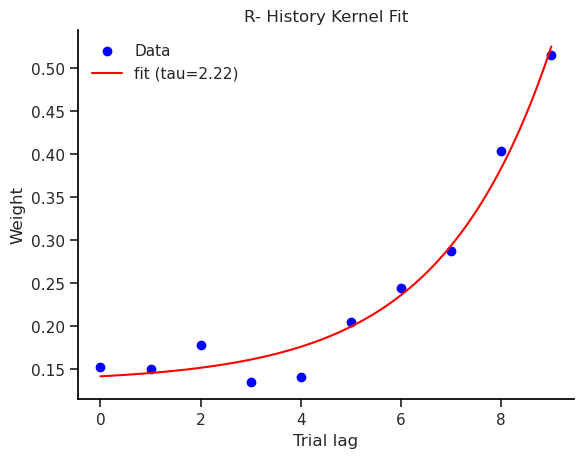

In [26]:
# Fit
x = np.arange(fk.trial_lag)
y = np.array(fk.params_rminus)

popt, pcov = curve_fit(exp_func, x, y, p0=(0.1, 1, 0.1))
A_fit, tau_fit, C_fit = popt
print('Fitted tau:', tau_fit)

# Generate smooth curve
x_fit = np.linspace(0, 9, 100)
y_fit = exp_func(x_fit, A_fit, tau_fit, C_fit)

# Plot
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x_fit, y_fit, color='red', label=f'fit (tau={tau_fit:.2f})')
plt.xlabel('Trial lag')
plt.ylabel('Weight')
plt.title('R- History Kernel Fit')
plt.legend()
sns.despine()

## R+

Fitted tau: 0.9538390367473449


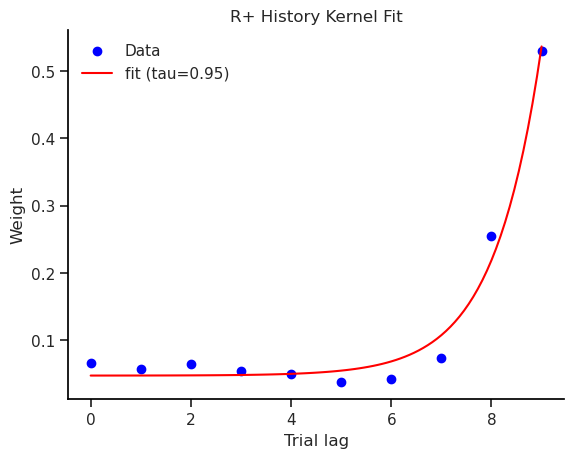

In [27]:
# Fit
x = np.arange(fk.trial_lag)
y = np.array(fk.params_rplus)

popt, pcov = curve_fit(exp_func, x, y, p0=(0.1, 1, 0.1))
A_fit, tau_fit, C_fit = popt
print('Fitted tau:', tau_fit)

# Generate smooth curve
x_fit = np.linspace(0, 9, 100)
y_fit = exp_func(x_fit, A_fit, tau_fit, C_fit)

# Plot
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x_fit, y_fit, color='red', label=f'fit (tau={tau_fit:.2f})')
plt.xlabel('Trial lag')
plt.ylabel('Weight')
plt.title('R+ History Kernel Fit')
plt.legend()
sns.despine()

In [24]:
np.mean([2.22, 0.95])

1.585

# Save all notebook's figures

In [ ]:
# # Whole notebook outputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
# save_notebook_files('notebook.ipynb')